In [1]:
import os
import numpy as np
from scipy.special import erf, erfinv
#from math import erf
from numpy.linalg import norm
from mlmm import VelocityData, plot_learn_curve, n_fold_cv, fileinfo,VelocityDataOmegaData, OmegaData

import matplotlib.pyplot as plt

from datetime import date
today = date.today().strftime("%b-%d-%Y")
import periodictable

import sys
from mlmm import func_postprocess
import time



er_type = 'MAE'

system_6D = False # Assignment A uses 6D data since we are using only the translational velocity data
system_10D = True
system_omega = True # Set to false, since we are not using angular velocity data in this assignment
wall_temp = 300
Liao_Transfer_Function = True

kB,conv_v,conv_omega,av_num = 1.38064852e-23,1.0e2,1.0e12,6.022e23




x_data = [
          ]
y_data = [
          ]

x_omega = []
y_omega = []

x_MD = []
y_MD = []

# Path to the data files for Task 1
# Materials_for_ML_assignment\H2_IsoThermalWalls_Sw_0\H2_Vel_MD_Sw_0_B300_Th_300.txt  
# Materials_for_ML_assignment\H2_NonIsoThermalWalls_Sw_0\H2_Vel_MD_Sw_0_T500_Tb_300.txt  
# Materials_for_ML_assignment\H2_NonIsoThermalWalls_Sw_0\H2_Vel_MD_Sw_0_B300_Th_500.txt

path_to_data = 'Data_H2_assignment_B'
path_save_data='./'+path_to_data
#path_to_data = 'Shahin/test_data/'



for file in os.listdir(path_to_data):

    if file.endswith(".txt") and "MD" in file:
        x_MD.append(os.path.join(path_to_data,file))
        y_MD.append('')

    if file.endswith(".txt") and "omega" in file:
        x_omega.append(os.path.join(path_to_data,file))
        y_omega.append('')
print("Data files found:",x_MD)


######################################################################################
#------------------------------- Getting translational velocity data
####--------------------------------------------------------------------------------------------------
for x_data_file,y_data_file in zip(x_MD,y_MD):
    

    conf = VelocityData(x_data_file, frames=None)#[0,30000])
    conf.getRep(rep='vxvyvz',nuc=None) #rep options: vxvyvz, vel2norm, vx2,vy2,vz2,vx,vy,vz
    file_name=x_data_file.replace('.','/')
    file_name=file_name.split('/')
    set_name = file_name[1]
    X = conf.X
    y = conf.y
    if "He" in path_to_data:
        mass = getattr(periodictable,'He').mass
        gas_name = 'He'
    elif "Ar" in path_to_data:
        mass = getattr(periodictable,'Ar').mass
        gas_name = 'Ar'
    elif "H2" in path_to_data:
        mass =2* getattr(periodictable,'H').mass
        gas_name = 'H2'
        l_b=0.741e-10
        mass_kg = mass * 0.001 / av_num
        I=(mass_kg/4)*l_b**2
    elif "N2" in path_to_data:
        mass =2* getattr(periodictable,'N').mass
        gas_name = 'N2'
        l_b=1.097e-10
        mass_kg = mass * 0.001 / av_num
        I=(mass_kg/4)*l_b**2
    else:
        print ("Unable to identify impinging atom type...")
        ele = str(input("Enter the impinging atom symbol : "))
        mass = getattr(periodictable,ele).mass
        v_mp = np.sqrt(2 * kB * wall_temp / mass_kg)
        omega_mp = np.sqrt(2 * kB * wall_temp / I)
    print ('Atomic mass for {} molecule is {:1.4f} \n'.format(gas_name,mass))
    n_MD = X.shape[0]
    print('Number of MD tr velocity data points: {} \n'.format(n_MD))
    # Implementing Liao Transfer function on perpendicular velocity component
    v_TF,T_in,T_out,theta_in,theta_out=func_postprocess.liao_transform(X,mass,'y')


######################################################################################
#------------------------------- Getting angular velocity data
####--------------------------------------------------------------------------------------------------
if system_omega:
    for x_data_file2,y_data_file2 in zip(x_omega,y_omega):
        #conf2 = OmegaData(x_data_file2, frames=frames)#[0,30000])
        conf2 = OmegaData(x_data_file2, frames=None)#[0,30000])
        conf2.getRep(rep='omega1omega2',nuc=None) #rep options: vxvyvz, vel2norm, vx2,vy2,vz2,vx,vy,vz
        omega_file_name = x_data_file2.replace('.','/')
        omega_file_name = omega_file_name.split('/')
        omega_name = omega_file_name[1]
        print(omega_name)
        X2 = conf2.X2
        y2 = conf2.y2
        print('Number of MD rot velocity data points: {} \n'.format(X2.shape[0]))
        X2_TF=np.copy(X2)
        Y2_TF=np.copy(y2)
        omega_TF=np.vstack((X2_TF,-X2_TF))
        y2_TF=np.hstack((Y2_TF,-Y2_TF))   

######################################################################################
#------------------------------- Implementing GM model on 10D data
####--------------------------------------------------------------------------------------------------                   

if system_10D:
    vel_tr = np.copy(X)
    vel_tr[:,1]=np.abs(vel_tr[:,1])
    vel_tr[:,4]=np.abs(vel_tr[:,4])
    data_for_AC_MD = np.concatenate((vel_tr,X2),axis=1)

    
    if Liao_Transfer_Function:
        #omega_bond = np.copy(X2)
        v_tr=np.copy(v_TF[:n_MD,:])
        v_omega = np.copy(X2)
        v_mp = np.sqrt(2 * kB * wall_temp / mass_kg)
        omega_mp = np.sqrt(2 * kB * wall_temp / I)
        #--- Normalazing the translational and rotational velocities
        data_train_10D = np.concatenate((v_tr*conv_v/v_mp,X2*conv_omega/omega_mp),axis=1)

        print('The total number of training points is: {} \n'.format(data_train_10D.shape[0]))
        
    else:
        data_train_10D = data_for_AC_MD
        print('The total number of training points is: {} \n'.format(data_train_10D.shape[0]))

Data files found: ['Data_H2_assignment_B\\H2_Vel_MD_Sw_0_B300_Th_300.txt', 'Data_H2_assignment_B\\H2_Vel_MD_Sw_0_B300_Th_500.txt', 'Data_H2_assignment_B\\H2_Vel_MD_Sw_0_T500_Tb_300.txt']
Generating Representation


0% [#####                         ] 100% | ETA: 00:00:00

Not a float


0% [##############################] 100% | ETA: 00:00:00
Total time elapsed: 00:00:00


Atomic mass for H2 molecule is 2.0160 

Number of MD tr velocity data points: 123351 

Generating Representation


...

txt
Number of MD rot velocity data points: 330030 

Generating Representation


0% [##                            ] 100% | ETA: 00:00:01

Not a float


0% [##############################] 100% | ETA: 00:00:00
Total time elapsed: 00:00:01


txt
Number of MD rot velocity data points: 325627 

The total number of training points is: 325627 



## Preprocessing data

In [2]:
# 1 GMM with PCA
import pandas as pd
X_df = pd.DataFrame(data_train_10D, copy=True)
X_df.columns = ['vx_in', 'vy_in', 'vz_in', 'vx_out', 'vy_out', 'vz_out', 'omega1_in', 'omega2_in', 'omega1_out', 'omega2_out']

X_df = X_df[:5000] # Take small percentage of data for testing
X_df

,vx_in,vy_in,vz_in,vx_out,vy_out,vz_out,omega1_in,omega2_in,omega1_out,omega2_out
0,1.994168,1.588206,-0.023016,-1.986874,0.020302,-0.585283,0.317431,-1.096155,-1.150343,-0.432556
1,-0.558343,-1.288154,0.174354,-0.747981,-1.490289,-0.446263,0.432063,-0.009135,-0.014347,-0.508998
2,0.329281,0.156454,0.638933,1.328772,0.298811,-0.567729,-1.813231,-0.030902,0.056909,-1.107153
3,-0.852010,-0.946877,-0.229184,0.851205,0.048447,-0.869905,0.859320,0.804164,0.949722,-0.726723
4,0.811189,-0.222759,-0.202905,0.966343,0.401869,1.168089,-1.476995,-1.309539,1.444379,-0.575907
...,...,...,...,...,...,...,...,...,...,...
4995,-0.112497,-1.120152,0.802489,-0.267917,-1.262219,0.136216,-0.781695,-0.348867,-0.118581,0.383100
4996,0.345677,-0.274721,0.279729,-1.096215,-1.330110,0.105945,-0.405933,-0.734078,-0.308898,-0.293849
4997,-1.277770,-1.836947,0.455894,-0.308436,-0.322703,-0.400524,0.159436,-0.098738,0.357204,-0.617617
4998,-0.473849,0.389103,-0.477835,-0.283687,0.255655,-0.199241,-0.035176,0.183755,0.167322,0.257591


## Plotting
#### Translational velocities

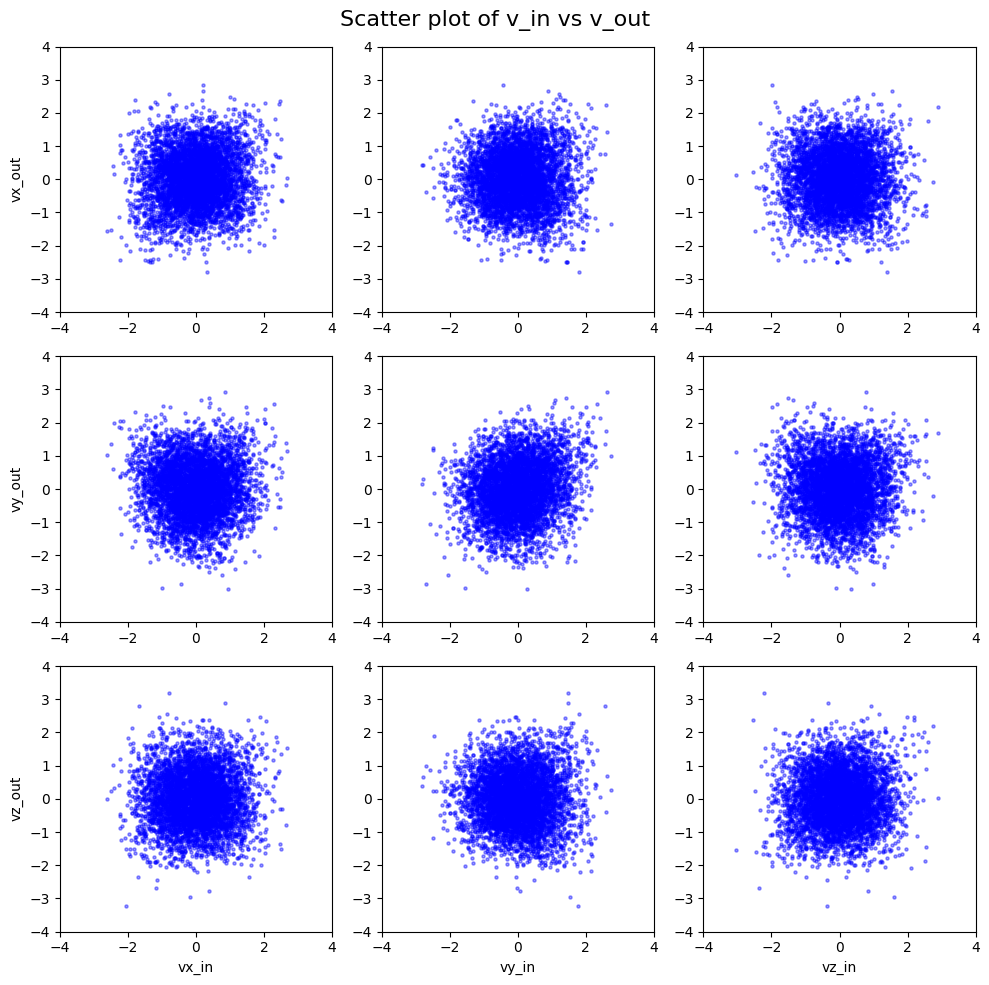

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(3, 3, figsize=(10, 10))
titles = ["x", "y", "z"]
for row in range(3):
    ax[row, 0].set_ylabel(f'v{titles[row]}_out')  
    ax[2, row].set_xlabel(f'v{titles[row]}_in')
    for column in range(3):
        v_in = X_df.iloc[:, column]  # Correctly select v_in for each column
        v_out = X_df.iloc[:, row + 3]  # Correctly select v_out for each row
        ax[row, column].scatter(v_in, v_out, c='blue', s=5, alpha=0.4, label='Data points')
        ax[row,column].set_xlim(-4,4)
        ax[row,column].set_ylim(-4,4)
fig.suptitle('Scatter plot of v_in vs v_out', fontsize=16)
fig.tight_layout()
plt.show()


#### Rotational velocities

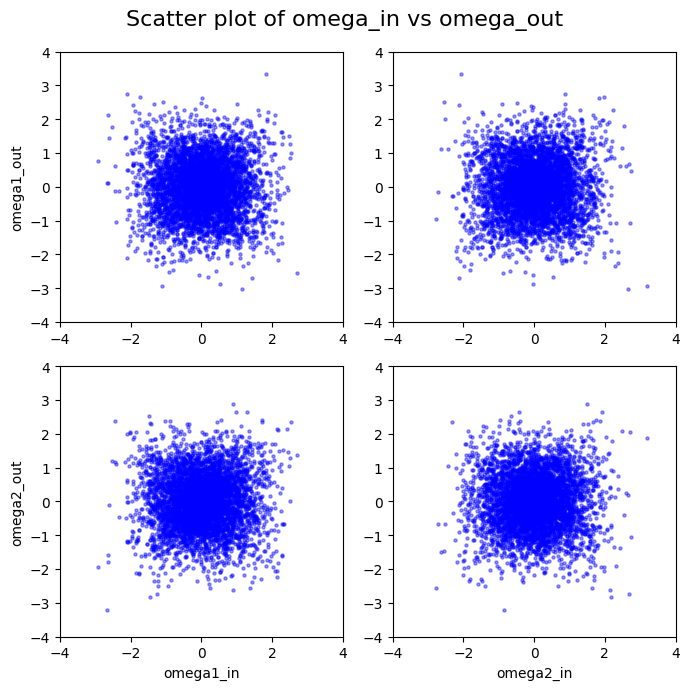

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(2, 2, figsize=(7, 7))
titles = ["1", "2"]
for row in range(2):
    ax[row, 0].set_ylabel(f'omega{titles[row]}_out')  
    ax[1, row].set_xlabel(f'omega{titles[row]}_in')
    for column in range(2):
        omega_in = X_df.iloc[:, column + 6]  # Correctly select v_in for each column
        omega_out = X_df.iloc[:, row + 8]  # Correctly select v_out for each row
        ax[row, column].scatter(omega_in, omega_out, c='blue', s=5, alpha=0.4, label='Data points')
        ax[row,column].set_xlim(-4,4)
        ax[row,column].set_ylim(-4,4)
fig.suptitle('Scatter plot of omega_in vs omega_out', fontsize=16)
fig.tight_layout()
plt.show()

## Find optimal model parameters

In [5]:
from sklearn.model_selection import GridSearchCV
from sklearn.mixture import GaussianMixture

# Find optimal number of commponents and covariance type using BIC score
def gmm_bic_score(estimator, X):
    """Callable to pass to GridSearchCV that will use the BIC score."""
    # Make it negative since GridSearchCV expects a score to maximize
    return -estimator.bic(X)

param_grid = {
    "n_components": range(1, 7),
    "covariance_type": ["spherical", "tied", "diag", "full"],
}

grid_search = GridSearchCV(
    GaussianMixture(), param_grid=param_grid, scoring=gmm_bic_score
)

grid_search.fit(X_df)

c:\Users\20193567\AppData\Local\miniconda3\envs\tensorflow_env\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\20193567\AppData\Local\miniconda3\envs\tensorflow_env\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\20193567\AppData\Local\miniconda3\envs\tensorflow_env\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\20193567\AppData\Local\miniconda3\envs\tensorflow_env\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\20193567\AppData\Local

GridSearchCV(estimator=GaussianMixture(),
             param_grid={'covariance_type': ['spherical', 'tied', 'diag',
                                             'full'],
                         'n_components': range(1, 7)},
             scoring=<function gmm_bic_score at 0x0000020CEDAA5FC0>)

## Train GMM model

In [12]:
# Set optimal model parameters found by GridSearchCV
nr_components = 2
covariance_type = 'spherical'
gmm_model = GaussianMixture(n_components=nr_components, covariance_type=covariance_type, random_state=0)
gmm_model.fit(X_df)

GaussianMixture(covariance_type='spherical', n_components=2, random_state=0)

In [16]:
pdf = gmm_model.predict_proba(X_df)
print(f"pdf: {pdf.shape}")

print(f"pdf: {pdf[:5]}")

pdf: (5000, 2)
pdf: [[0.01475724 0.98524276]
 [0.9311236  0.0688764 ]
 [0.39004798 0.60995202]
 [0.74824725 0.25175275]
 [0.25067165 0.74932835]]


## Plotting pdf

#### Translational velocities

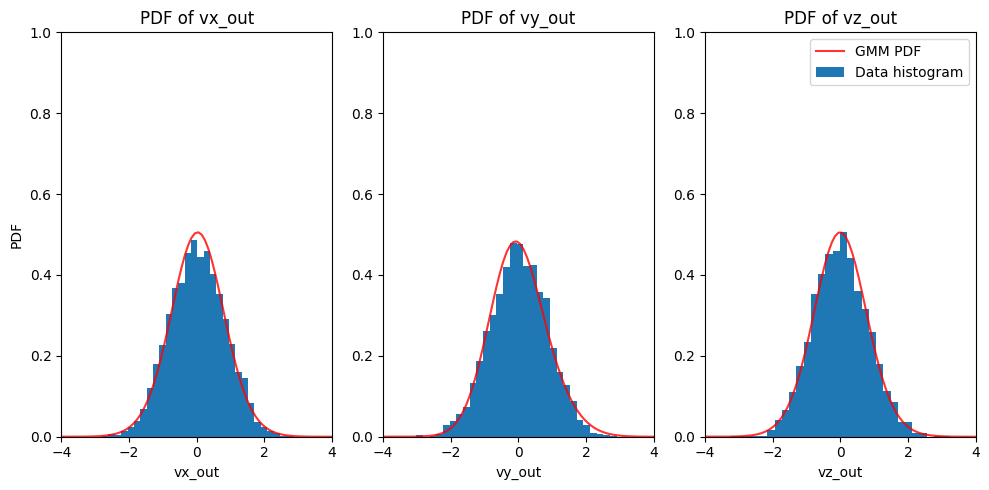

In [ ]:
import scipy.stats


# Extract marginal pdf for each feature from the GMM model
fig, ax = plt.subplots(1, 3, figsize=(10, 5))

titles = ["vx_out", "vy_out", "vz_out"]
feature_index = [3, 4, 5]
xlim = np.linspace(-50, 50, 1000)

for i in range(3):
    pdf = np.zeros_like(xlim)

    for j in range(nr_components):
        # Extract the mean, covariance, and weight for each gmm component
        mean = gmm_model.means_[j, feature_index[i]]
        cov = gmm_model.covariances_[j]
        weight = gmm_model.weights_[j]
        # Calculate the pdf for each component
        pdf += weight * scipy.stats.norm.pdf(xlim, loc=mean, scale=np.sqrt(cov)) 

    # Visualize the pdf as a line plot
    ax[i].plot(xlim, pdf, c='red', alpha=0.8, label='GMM PDF')
    ax[i].hist(X_df.iloc[:,feature_index[i]], bins=30, density=True, label='Data histogram')
    ax[i].set_xlim([-4, 4])
    ax[i].set_ylim([0, 1])
    ax[i].set_xlabel(f'{titles[i]}')
    ax[i].set_title(f'PDF of {titles[i]}')
ax[0].set_ylabel("PDF")
ax[2].legend(loc=1)
fig.tight_layout()
plt.show()


#### Rotational velocities

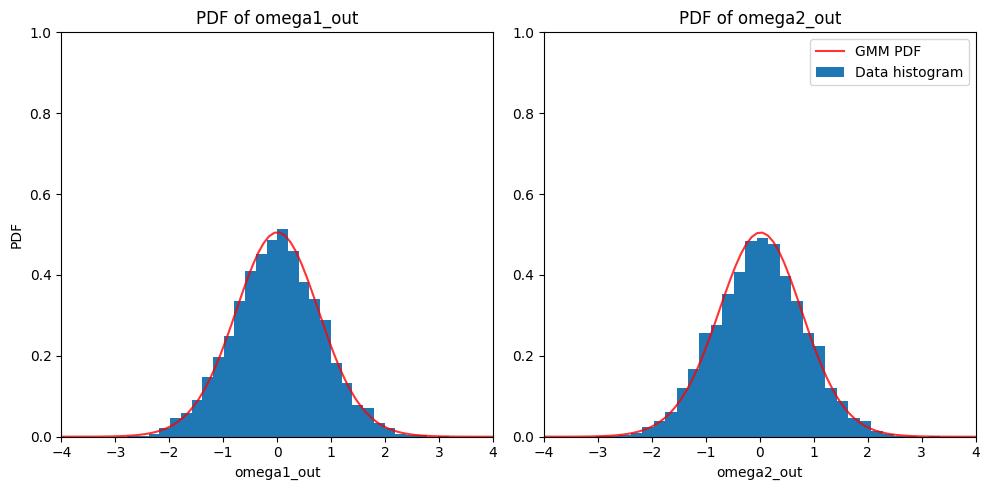

In [18]:
import scipy.stats


# Extract marginal pdf for each feature from the GMM model
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

titles = ["omega1_out", "omega2_out"]
feature_index = [7, 8]
xlim = np.linspace(-50, 50, 1000)

for i in range(2):
    pdf = np.zeros_like(xlim)

    for j in range(nr_components):
        # Extract the mean, covariance, and weight for each gmm component
        mean = gmm_model.means_[j, feature_index[i]]
        cov = gmm_model.covariances_[j]
        weight = gmm_model.weights_[j]
        # Calculate the pdf for each component
        pdf += weight * scipy.stats.norm.pdf(xlim, loc=mean, scale=np.sqrt(cov)) 

    # Visualize the pdf as a line plot
    ax[i].plot(xlim, pdf, c='red', alpha=0.8, label='GMM PDF')
    ax[i].hist(X_df.iloc[:,feature_index[i]], bins=30, density=True, label='Data histogram')
    ax[i].set_xlim([-4, 4])
    ax[i].set_ylim([0, 1])
    ax[i].set_xlabel(f'{titles[i]}')
    ax[i].set_title(f'PDF of {titles[i]}')
ax[0].set_ylabel("PDF")
ax[1].legend(loc=1)
fig.tight_layout()
plt.show()
